# Electricity demand and lighting comfort: exploratory analysis

**Business question:** How much can peak electricity demand be reduced in each zone without compromising lighting comfort?

This notebook checks all 14 CSV files, compares floors and zones, and estimates **conditional lighting-only reductions**. It does not treat historical lux measurements as proof that dimming is safe. Each zone means a **floor + zone pair**; `z1` on two floors is not the same space.

Run the notebook in the folder containing the CSV files. Required packages: `pandas`, `numpy`, `matplotlib`, and `ipykernel`. Use **Restart Kernel and Run All**. The code uses basic loops, pandas summaries, and matplotlib. Source files are never changed.

The CSV files are the selected input format. The similarly named Excel files are not loaded as additional observations; their equivalence to the CSVs has not been established. The extra `2019Floor2(1).xlsx` is also excluded from ingestion.

**Repository copy:** supports the shared `SBA_Kaggle_Dataset/data` directory and explicit file-wide date parsing, including day-first slash dates. The analysis retains the original full-zone-year screening method. Coverage is measured within each observed file span, so missing periods beyond a truncated file end are not included in its denominator.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Support the repository layout and the original standalone CSV folder.
DATA_DIR = next((candidate for parent in [Path.cwd(), *Path.cwd().parents]
                 for candidate in [parent / "SBA_Kaggle_Dataset" / "data", parent / "data", parent]
                 if len(list(candidate.glob("20??Floor?.csv"))) == 14), Path.cwd())
FILES = sorted(DATA_DIR.glob("20??Floor?.csv"))
assert len(FILES) == 14, "Expected 14 CSV files: 2018/2019, floors 1 to 7."
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 16)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.spines.top": False,
                     "axes.spines.right": False})

# Illustrative assumptions, NOT a required lighting standard or known work schedule.
TARGET_LUX = 500
LUX_TARGETS = [300, 500, 750]
MAX_DIM = 0.20
START_HOUR, END_HOUR = 8, 18
MIN_COVERAGE = 0.80
MIN_PEAK_PAIRS = 30

# Reuse the repository parser to support its day-first Floor 7 CSV.
def parse_dates(series, slash_order=None):
    """Parse ISO and file-level slash dates using unambiguous >12 day evidence.

    Floor 7's local 2019 file uses day/month/year. Do not guess each row:
    4/1/19 means January 4 in that entire file, not April 1. An all-ambiguous
    slash-date file needs an explicit 'dayfirst' or 'monthfirst' override.
    """
    text = series.astype('string').str.strip()
    iso = text.str.match(r'^\d{4}-', na=False)
    out = pd.Series(pd.NaT, index=series.index, dtype='datetime64[ns]')
    out.loc[iso] = pd.to_datetime(text.loc[iso], format='ISO8601', errors='coerce')
    slash = text.str.match(r'^\d{1,2}/\d{1,2}/\d{2} ', na=False)
    if slash.any():
        pieces = text.loc[slash].str.extract(r'^(\d{1,2})/(\d{1,2})/')
        first_day_evidence = pd.to_numeric(pieces[0]).gt(12).any()
        second_day_evidence = pd.to_numeric(pieces[1]).gt(12).any()
        if slash_order is None:
            if first_day_evidence and second_day_evidence:
                raise ValueError('Mixed slash-date conventions: resolve at source.')
            if not first_day_evidence and not second_day_evidence:
                raise ValueError('Ambiguous slash-date file: specify slash_order.')
            slash_order = 'dayfirst' if first_day_evidence else 'monthfirst'
        if slash_order not in ['dayfirst', 'monthfirst']:
            raise ValueError('slash_order must be dayfirst or monthfirst')
        fmt = '%d/%m/%y %H:%M' if slash_order == 'dayfirst' else '%m/%d/%y %H:%M'
        out.loc[slash] = pd.to_datetime(text.loc[slash], format=fmt, errors='coerce')
    # Local building clock, Bangkok (UTC+7); no conversion to Singapore clock.
    return out

## 1. Read and audit the raw data

Read one file at a time to keep memory use manageable. Check timestamps, missing values, negative readings, constants, and sampling gaps **before** aggregation. Retain large positive readings for investigation instead of automatically deleting possible real peaks.

For analysis, invalid numeric values and negative power/lux are made missing. Exact duplicate rows are removed; conflicting duplicate timestamps are excluded entirely. No gaps are filled. Temperature and humidity are audited but not used to calculate lighting reductions.

Power is averaged into **15-minute intervals**, an analytical choice rather than a verified tariff interval. Every contributing meter must have all 15 minute readings before a zone total is accepted. Lux uses the **minimum observed minute reading** in each complete interval so an interval average cannot conceal a brief low reading. Timezone and meter placement are not documented.

In [2]:
file_rows, column_rows, zone_frames = [], [], []

for path in FILES:
    year, floor = map(int, re.findall(r"\d+", path.stem))
    raw = pd.read_csv(path)
    dates = parse_dates(raw["Date"])
    numeric = raw.drop(columns="Date").apply(pd.to_numeric, errors="coerce")
    for col in numeric:
        s = numeric[col]
        column_rows.append({"file": path.name, "floor": floor, "year": year,
                            "column": col, "missing_pct": 100 * s.isna().mean(),
                            "negative_n": int(s.lt(0).sum()), "unique_n": s.nunique(),
                            "zero_pct": 100 * s.eq(0).mean(),
                            "min": s.min(), "median": s.median(), "max": s.max()})
    exact_duplicates = int(raw.duplicated().sum())
    data = numeric.copy()
    data["Date"] = dates
    data = data.loc[~raw.duplicated()].dropna(subset=["Date"])
    conflict_rows = int(data["Date"].duplicated(keep=False).sum())
    data = data.loc[~data["Date"].duplicated(keep=False)].set_index("Date").sort_index()
    expected = int((data.index.max() - data.index.min()).total_seconds() / 60) + 1
    off_grid = int((data.index != data.index.floor("min")).sum())
    assert off_grid == 0, "Review timestamps that do not fall on whole minutes."
    steps = data.index.to_series().diff().dt.total_seconds().div(60)
    file_rows.append({"file": path.name, "rows": len(raw), "columns": len(numeric.columns),
                      "start": data.index.min(), "end": data.index.max(),
                      "bad_dates": int(dates.isna().sum()), "exact_duplicates": exact_duplicates,
                      "conflict_rows": conflict_rows, "missing_minutes": expected - len(data),
                      "typical_step_min": steps.median(), "largest_gap_min": steps.max(),
                      "missing_cells_pct": 100 * numeric.isna().mean().mean()})
    clean_cols = [c for c in data if c.endswith("(kW)") or c.endswith("(lux)")]
    data[clean_cols] = data[clean_cols].mask(data[clean_cols] < 0)
    data = data.replace([np.inf, -np.inf], np.nan)
    means = data.resample("15min").mean()
    counts = data.resample("15min").count()
    means = means.where(counts == 15)
    minimums = data.resample("15min").min().where(counts == 15)

    zones = sorted({c.split("_")[0] for c in data})
    for zone in zones:
        power_cols = [c for c in data if c.startswith(zone + "_") and c.endswith("(kW)")]
        light_cols = [c for c in power_cols if "_Light" in c]
        ac_cols = [c for c in power_cols if "_AC" in c]
        plug_cols = [c for c in power_cols if "_Plug" in c]
        lux_cols = [c for c in data if c.startswith(zone + "_") and c.endswith("(lux)")]
        frame = pd.DataFrame(index=means.index)
        frame["total_kw"] = means[power_cols].sum(axis=1, min_count=len(power_cols))
        frame["light_kw"] = means[light_cols].sum(axis=1, min_count=len(light_cols))
        frame["ac_kw"] = means[ac_cols].sum(axis=1, min_count=len(ac_cols)) if ac_cols else np.nan
        frame["plug_kw"] = means[plug_cols].sum(axis=1, min_count=len(plug_cols)) if plug_cols else np.nan
        frame["lux_min"] = minimums[lux_cols].min(axis=1) if lux_cols else np.nan
        frame["lux_mean"] = means[lux_cols].mean(axis=1) if lux_cols else np.nan
        frame["has_lux"] = bool(lux_cols)
        frame["meter_count"] = len(power_cols)
        frame["floor"], frame["zone"], frame["year"] = floor, zone, year
        frame["zone_id"] = f"F{floor}-{zone}"
        zone_frames.append(frame.reset_index())
    print(f"Read {path.name}: {len(raw):,} rows")

files = pd.DataFrame(file_rows)
columns = pd.DataFrame(column_rows)
df = pd.concat(zone_frames, ignore_index=True)
df["hour"] = df["Date"].dt.hour
df["weekday"] = df["Date"].dt.dayofweek
df["work_hours"] = (df["weekday"] < 5) & df["hour"].between(START_HOUR, END_HOUR - 1)
display(files)
print(f"Total raw rows: {files['rows'].sum():,}; unique floor-zone pairs: {df['zone_id'].nunique()}")

Read 2018Floor1.csv: 264,960 rows


Read 2018Floor2.csv: 264,960 rows


Read 2018Floor3.csv: 264,960 rows


Read 2018Floor4.csv: 264,960 rows


Read 2018Floor5.csv: 264,960 rows


...

Read 2019Floor5.csv: 525,600 rows


Read 2019Floor6.csv: 424,169 rows


Read 2019Floor7.csv: 525,600 rows


,file,rows,columns,start,end,bad_dates,exact_duplicates,conflict_rows,missing_minutes,typical_step_min,largest_gap_min,missing_cells_pct
0,2018Floor1.csv,264960,11,2018-07-01,2018-12-31 23:59:00,0,0,0,0,1.00,1.00,1.43
1,2018Floor2.csv,264960,36,2018-07-01,2018-12-31 23:59:00,0,0,0,0,1.00,1.00,23.82
2,2018Floor3.csv,264960,29,2018-07-01,2018-12-31 23:59:00,0,0,0,0,1.00,1.00,40.23
3,2018Floor4.csv,264960,29,2018-07-01,2018-12-31 23:59:00,0,0,0,0,1.00,1.00,34.17
4,2018Floor5.csv,264960,29,2018-07-01,2018-12-31 23:59:00,0,0,0,0,1.00,1.00,27.02
5,2018Floor6.csv,264960,29,2018-07-01,2018-12-31 23:59:00,0,0,0,0,1.00,1.00,25.56
6,2018Floor7.csv,264960,29,2018-07-01,2018-12-31 23:59:00,0,0,0,0,1.00,1.00,25.41
7,2019Floor1.csv,525600,11,2019-01-01,2019-12-31 23:59:00,0,0,0,0,1.00,1.00,0.14
8,2019Floor2.csv,525600,36,2019-01-01,2019-12-31 23:59:00,0,0,0,0,1.00,1.00,7.15
9,2019Floor3.csv,525600,29,2019-01-01,2019-12-31 23:59:00,0,0,0,0,1.00,1.00,11.08


Total raw rows: 5,432,489; unique floor-zone pairs: 33


In [3]:
# Problem columns: a constant can be a real idle device, not necessarily a broken sensor.
issues = columns[(columns["missing_pct"] > 20) | (columns["negative_n"] > 0) |
                 (columns["unique_n"] <= 1)]
display(issues.sort_values(["floor", "year", "column"]))
print("Issue columns:", len(issues), "out of", len(columns))
display(columns.groupby("year")[["missing_pct", "negative_n"]].agg(["mean", "max"]))

,file,floor,year,column,missing_pct,negative_n,unique_n,zero_pct,min,median,max
15,2018Floor2.csv,2,2018,z1_S1(RH%),61.53,0,2119,0.00,46.28,56.54,72.80
14,2018Floor2.csv,2,2018,z1_S1(degC),61.53,0,827,0.00,21.26,26.77,30.90
16,2018Floor2.csv,2,2018,z1_S1(lux),61.53,0,97,18.53,0.00,2.00,96.00
27,2018Floor2.csv,2,2018,z2_AC11(kW),0.19,0,1,99.81,0.00,0.00,0.00
34,2018Floor2.csv,2,2018,z2_S1(RH%),61.63,0,2368,0.00,49.60,62.47,80.69
...,...,...,...,...,...,...,...,...,...,...,...
375,2019Floor7.csv,7,2019,z4_S1(degC),20.81,0,1548,0.00,17.53,26.33,35.73
377,2019Floor7.csv,7,2019,z4_S1(lux),20.81,0,74,40.21,0.00,0.00,73.00
382,2019Floor7.csv,7,2019,z5_S1(RH%),22.43,0,4242,0.00,37.14,65.43,84.92
381,2019Floor7.csv,7,2019,z5_S1(degC),22.43,0,1294,0.00,19.14,26.67,34.40


Issue columns: 145 out of 384


missing_pct        negative_n    
            mean    max       mean max
year                                  
2018       27.57 100.00       0.00   0
2019       10.14  42.57       0.00   0

## 2. Coverage, distributions, and sensor suitability

Coverage below is the percentage of expected 15-minute intervals in each source file's date span. A missing sensor is different from a sensor recording zero. A zero-lux reading may reflect darkness, a covered sensor, or a fault; this dataset alone cannot distinguish them.

The working-hours filter is only a weekday 08:00–18:00 proxy. It does not establish occupancy, holidays, or whether an area is used at night. Totals mean the **sum of available zone meter channels**, whose completeness and circuit independence still require a meter map.

expected_intervals  total_coverage  light_coverage  \
year floor zone_id                                                       
2018 1     F1-z1                 17664           98.90           98.90   
           F1-z2                 17664           87.20           99.00   
           F1-z3                 17664           98.90           99.50   
           F1-z4                 17664           99.50           99.50   
     2     F2-z1                 17664           99.70           99.80   
           F2-z2                 17664           99.50           99.80   
           F2-z3                 17664           99.80           99.80   
           F2-z4                 17664           99.40           99.80   
     3     F3-z1                 17664           72.50           77.60   
           F3-z2                 17664           77.40           77.40   
           F3-z3                 17664           77.50           77.60   
           F3-z4                 17664           75.20           75.20   
           F3-z5                 17664           75.20           75.20   
     4     F4-z1                 17664           73.10           78.70   
           F4-z2                 17664           78.50           78.70   
           F4-z3                 17664           87.30           87.30   
           F4-z4                 17664           81.30           81.40   
           F4-z5                 17664           81.30           81.40   
     5     F5-z1                 17664           95.40           97.00   
           F5-z2                 17664           93.00           93.80   
           F5-z3                 17664           96.70           96.70   
           F5-z4                 17664           91.40           91.50   
           F5-z5                 17664           91.40           91.50   
     6     F6-z1                 17664           99.40           99.50   
           F6-z2                 17664           99.50           99.50   
           F6-z3                 17664           99.80           99.80   
           F6-z4                 17664           89.60           94.40   
           F6-z5                 17664           93.20           93.20   
     7     F7-z1                 17664           99.70           99.80   
           F7-z2                 17664           99.70           99.80   
           F7-z3                 17664           99.80           99.80   
           F7-z4                 17664           99.70           99.80   
           F7-z5                 17664           99.70           99.80   
2019 1     F1-z1                 35040           99.00           99.00   
           F1-z2                 35040           99.20           99.90   
           F1-z3                 35040           99.50           99.90   
           F1-z4                 35040           99.90           99.90   
     2     F2-z1                 35040           94.30           99.90   
           F2-z2                 35040           94.10           99.60   
           F2-z3                 35040           99.90           99.90   
           F2-z4                 35040           94.10           97.70   
     3     F3-z1                 35040           90.70           99.80   
           F3-z2                 35040           91.40           98.20   
           F3-z3                 35040           99.80           99.90   
           F3-z4                 35040           88.70           95.20   
           F3-z5                 35040           89.10           95.20   
     4     F4-z1                 35040           72.20           93.40   
           F4-z2                 35040           92.50           93.40   
           F4-z3                 35040           99.60           99.70   
           F4-z4                 35040           96.40           97.50   
           F4-z5                 35040           96.70           97.50   
     5     F5-z1                 35040           92.90           99.50   
           F5-z2        

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
total_kw,"1,594,039.00",7.72,14.66,0.00,0.00,0.11,0.66,7.85,36.48,72.20,332.39
light_kw,"1,634,282.00",2.78,6.51,0.00,0.00,0.00,0.21,2.81,13.61,35.53,330.61
ac_kw,"1,159,511.00",5.70,11.62,0.00,0.00,0.00,0.00,6.29,31.09,47.28,106.92
plug_kw,"1,598,307.00",0.89,2.81,0.00,0.00,0.06,0.23,0.46,2.69,16.75,36.59
lux_min,"738,207.00",16.30,23.90,0.00,0.00,0.00,0.00,36.00,65.00,76.00,136.00


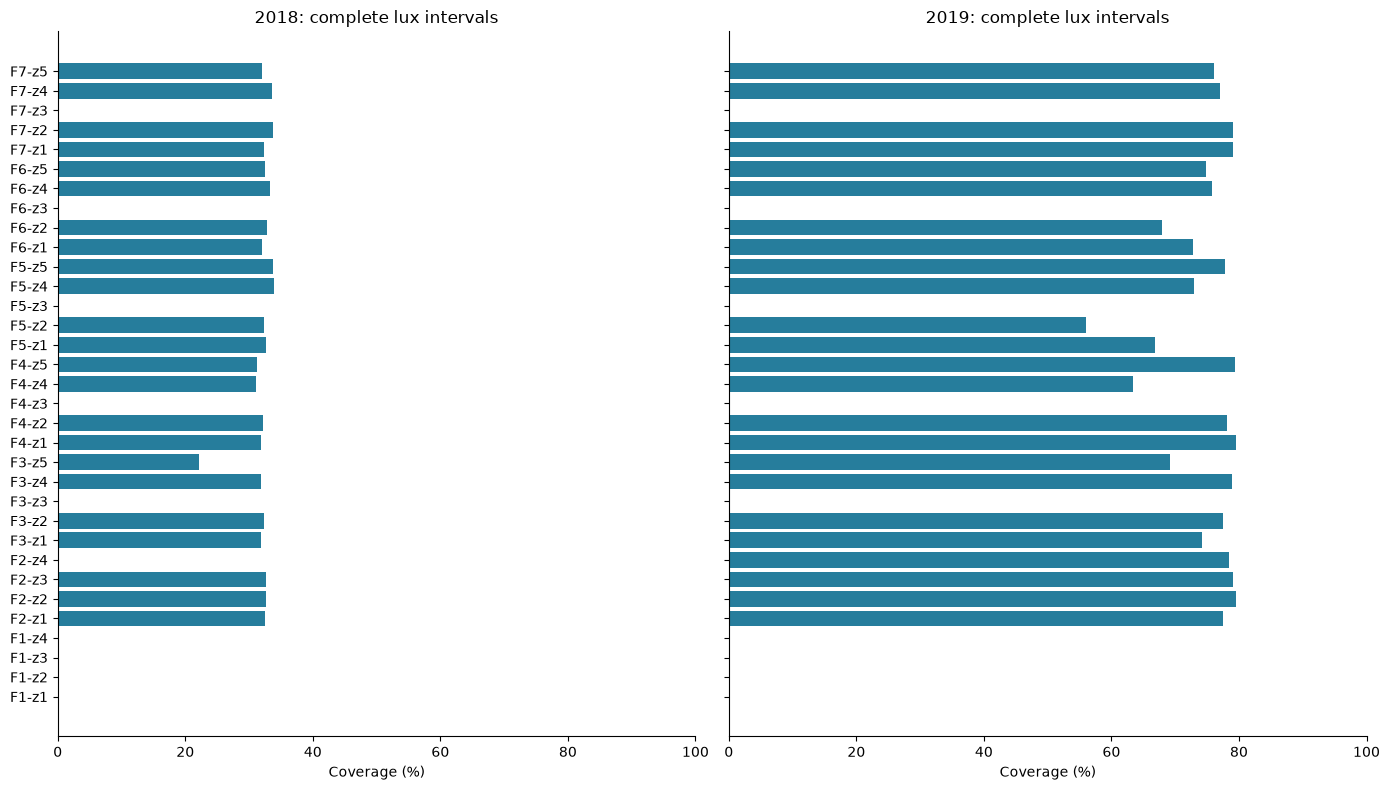

In [4]:
coverage = df.groupby(["year", "floor", "zone_id"]).agg(
    expected_intervals=("Date", "size"),
    total_coverage=("total_kw", lambda s: 100 * s.notna().mean()),
    light_coverage=("light_kw", lambda s: 100 * s.notna().mean()),
    lux_coverage=("lux_min", lambda s: 100 * s.notna().mean()),
    has_lux=("has_lux", "first"), meter_count=("meter_count", "first"))
display(coverage.round(1))
display(df[["total_kw", "light_kw", "ac_kw", "plug_kw", "lux_min"]]
        .describe(percentiles=[.01, .25, .5, .75, .95, .99]).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
for ax, year in zip(axes, [2018, 2019]):
    plot_data = coverage.loc[year].reset_index().set_index("zone_id")
    ax.barh(plot_data.index, plot_data["lux_coverage"], color="#267d9c")
    ax.set(title=f"{year}: complete lux intervals", xlabel="Coverage (%)", xlim=(0, 100))
plt.tight_layout()
plt.show()

## 3. When is demand high, and how much is lighting?

Compare daily and hourly patterns and each zone's lighting contribution **at its own total-demand peak**. Lighting's share at that instant is a ceiling on instantaneous lighting-only reduction; it is not a comfort-preserving saving or the reduction in the maximum after control. Do not add separate zone peaks together as a building peak.

2018 and 2019 may cover different months. Monthly tables retain coverage counts; comparing annual sums would confound time coverage with changes in use. Power in kW is never summed over time and called energy.

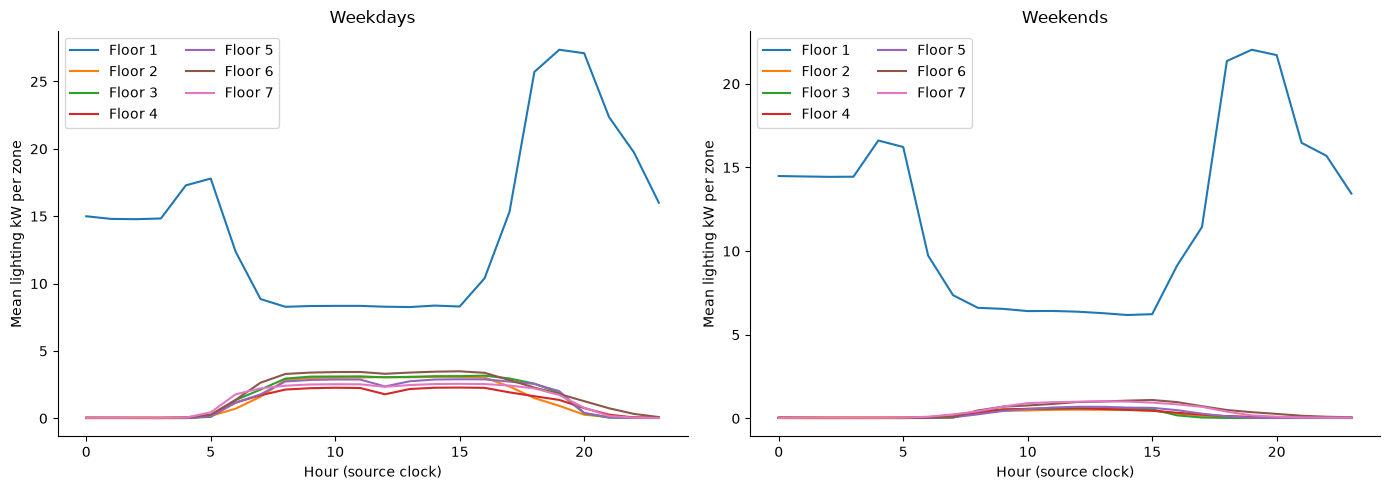

mean_zone_kw  p95_zone_kw  valid_intervals
Date    floor                                            
2018-07 1             31.15        80.47            11804
        2              8.03        37.16            11889
        3              4.23        26.72            14880
        4              4.13        25.33            13820
        5              4.15        25.03            14595
...                     ...          ...              ...
2019-12 2              5.69        32.76            11893
        3              3.34        21.48            14214
        4              3.40        21.01            14231
        5              3.38        21.37            14533
        7              4.51        31.63            14849

[124 rows x 3 columns]

,year,zone_id,peak_time,peak_kw,light_at_peak_kw,light_share_pct,lux_min_at_peak
0,2018,F1-z1,2018-08-30 21:30:00,71.63,50.14,70.00,NaN
1,2018,F1-z2,2018-08-12 12:30:00,132.96,18.16,13.66,NaN
2,2018,F1-z3,2018-09-11 09:45:00,332.39,330.61,99.47,NaN
3,2018,F1-z4,2018-08-30 19:30:00,65.69,65.69,100.00,NaN
4,2018,F2-z1,2018-07-23 10:15:00,53.04,8.90,16.78,84.00
5,2018,F2-z2,2018-07-05 13:00:00,43.11,2.31,5.37,107.00
6,2018,F2-z3,2018-07-16 06:45:00,4.00,1.39,34.75,0.00
7,2018,F2-z4,2018-09-04 11:30:00,13.55,2.15,15.88,NaN
8,2018,F3-z1,2018-07-06 08:00:00,36.84,4.58,12.43,41.00
9,2018,F3-z2,2018-09-25 10:30:00,34.28,6.51,18.99,NaN


In [5]:
hourly = df.groupby(["floor", "weekday", "hour"])["light_kw"].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for floor in sorted(df["floor"].unique()):
    h = hourly[hourly["floor"] == floor]
    axes[0].plot(h[h["weekday"] < 5].groupby("hour")["light_kw"].mean(), label=f"Floor {floor}")
    axes[1].plot(h[h["weekday"] >= 5].groupby("hour")["light_kw"].mean(), label=f"Floor {floor}")
for ax, title in zip(axes, ["Weekdays", "Weekends"]):
    ax.set(title=title, xlabel="Hour (source clock)", ylabel="Mean lighting kW per zone")
    ax.legend(ncol=2)
plt.tight_layout()
plt.show()

monthly = df.groupby([df["Date"].dt.to_period("M"), "floor"]).agg(
    mean_zone_kw=("total_kw", "mean"), p95_zone_kw=("total_kw", lambda s: s.quantile(.95)),
    valid_intervals=("total_kw", "count"))
display(monthly)

peak_rows = []
for (year, zone), g in df.groupby(["year", "zone_id"]):
    valid = g.dropna(subset=["total_kw"])
    if valid.empty:
        continue
    row = valid.loc[valid["total_kw"].idxmax()]
    peak_rows.append({"year": year, "zone_id": zone, "peak_time": row["Date"],
                      "peak_kw": row["total_kw"], "light_at_peak_kw": row["light_kw"],
                      "light_share_pct": 100 * row["light_kw"] / row["total_kw"] if row["total_kw"] > 0 else np.nan,
                      "lux_min_at_peak": row["lux_min"]})
peaks = pd.DataFrame(peak_rows)
display(peaks)

## 4. Lighting versus measured illuminance

Check whether high lighting power coincides with high or low lux. Correlation is descriptive: occupancy, daylight, blinds, and schedules can affect both variables. High correlation does not establish a dimming response, and low correlation does not prove a sensor is faulty.

The table includes low-lux observations during assumed working hours and off-hours lighting. Neither is automatically waste or discomfort because actual occupancy and sensor positions are unknown.

,year,zone_id,work_pairs,work_pair_coverage_pct,lux_unique,work_lux_median,below_target_pct,zero_lux_lights_on_pct,light_lux_corr,work_light_kw,offhours_light_kw
0,2018,F1-z1,0,0.00,0,NaN,NaN,NaN,NaN,1.00,8.64
1,2018,F1-z2,0,0.00,0,NaN,NaN,NaN,NaN,14.53,14.87
2,2018,F1-z3,0,0.00,0,NaN,NaN,NaN,NaN,25.15,22.99
3,2018,F1-z4,0,0.00,0,NaN,NaN,NaN,NaN,2.40,23.33
4,2018,F2-z1,1677,32.00,61,78.00,100.00,0.66,0.90,7.90,0.92
5,2018,F2-z2,1705,32.54,86,105.00,100.00,0.06,0.73,1.84,0.12
6,2018,F2-z3,1696,32.37,11,5.00,100.00,1.77,0.15,0.88,0.36
7,2018,F2-z4,0,0.00,0,NaN,NaN,NaN,NaN,1.85,0.20
8,2018,F3-z1,1572,30.00,34,36.00,100.00,0.83,0.78,4.52,0.66
9,2018,F3-z2,1663,31.74,29,75.00,100.00,0.06,0.96,5.58,0.85


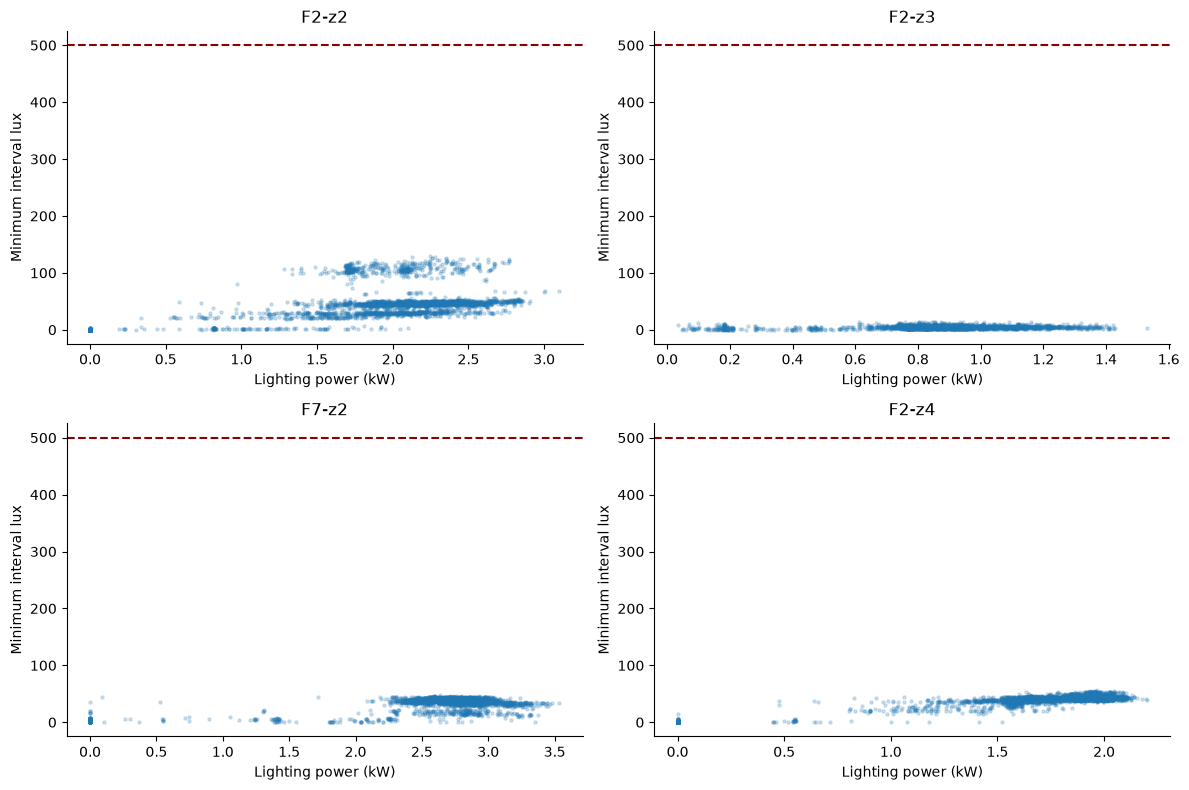

In [6]:
sensor_rows = []
for (year, zone), g in df.groupby(["year", "zone_id"]):
    work = g[g["work_hours"]]
    paired = work.dropna(subset=["light_kw", "lux_min"])
    off = g[~g["work_hours"]]
    sensor_rows.append({"year": year, "zone_id": zone,
        "work_pairs": len(paired),
        "work_pair_coverage_pct": 100 * len(paired) / len(work) if len(work) else np.nan,
        "lux_unique": paired["lux_min"].nunique(),
        "work_lux_median": paired["lux_min"].median(),
        "below_target_pct": 100 * paired["lux_min"].lt(TARGET_LUX).mean(),
        "zero_lux_lights_on_pct": 100 * ((paired["lux_min"] == 0) & (paired["light_kw"] > .1)).mean(),
        "light_lux_corr": paired["light_kw"].corr(paired["lux_min"]) if paired["light_kw"].nunique() > 1 and paired["lux_min"].nunique() > 1 else np.nan,
        "work_light_kw": work["light_kw"].mean(), "offhours_light_kw": off["light_kw"].mean()})
sensors = pd.DataFrame(sensor_rows)
display(sensors)

plot_zones = sensors.sort_values("work_pairs", ascending=False)["zone_id"].drop_duplicates().head(4)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, zone in zip(axes.flat, plot_zones):
    sample = df[(df["zone_id"] == zone) & df["work_hours"]].dropna(subset=["light_kw", "lux_min"])
    sample = sample.sample(min(3000, len(sample)), random_state=7)
    ax.scatter(sample["light_kw"], sample["lux_min"], s=5, alpha=.2)
    ax.axhline(TARGET_LUX, color="darkred", linestyle="--")
    ax.set(title=zone, xlabel="Lighting power (kW)", ylabel="Minimum interval lux")
plt.tight_layout()
plt.show()

## 5. Conditional reduction scenarios for every zone

**No positive reduction is verified to preserve comfort by these observational data alone.** The following is a screening calculation for a pilot, not an implemented control strategy or causal estimate.

Assume measured illuminance responds linearly to lighting power, daylight stays unchanged during a reduction, the sensor represents the occupied task area, and fixtures can dim. For a lux target `T`, use:

`fraction = min(20%, max(0, 1 - T / minimum_lux))`

`candidate_cut_kW = lighting_kW × fraction`

Applying the fraction to **all** measured lux treats daylight as if it also decreased, making this calculation conservative under those assumptions. It is not conservative against poor sensor placement, nonlinear fixture response, or changing daylight. The 20% cap is an illustrative pilot limit, not an established safe value. The targets 300/500/750 lux are sensitivity assumptions, not certified requirements for these spaces. No change is assumed outside proxy work hours or when data are missing/below target. Existing below-target conditions are flagged, not corrected by this calculation.

Zone high-demand intervals are the top 5% of valid zone totals **within each year**. A zone-year is screened in only if paired power/lux coverage in work hours is at least 80%, lux varies, and at least 30 paired high-demand work intervals exist. These are transparent analyst screening rules.

We report both the cut at the original peak and the actual difference between the original maximum and the maximum of the simulated series. A new peak can occur elsewhere. Missing comfort data produce **unavailable estimates** for excluded zone-years, not zero achievable savings.

,year,zone_id,status,pair_coverage_pct,peak_pairs,baseline_peak_kw,cut_at_old_peak_kw,scenario_peak_reduction_kw,scenario_peak_reduction_pct,mean_cut_high_work_kw,high_work_above_target_pct
1,2018,F1-z1,Demand only: no lux sensor,0.00,0,71.63,NaN,NaN,NaN,NaN,NaN
4,2018,F1-z2,Demand only: no lux sensor,0.00,0,132.96,NaN,NaN,NaN,NaN,NaN
7,2018,F1-z3,Demand only: no lux sensor,0.00,0,332.39,NaN,NaN,NaN,NaN,NaN
10,2018,F1-z4,Demand only: no lux sensor,0.00,0,65.69,NaN,NaN,NaN,NaN,NaN
13,2018,F2-z1,Review: incomplete paired data,31.98,357,53.04,NaN,NaN,NaN,NaN,0.00
16,2018,F2-z2,Review: incomplete paired data,32.35,535,43.11,NaN,NaN,NaN,NaN,0.00
19,2018,F2-z3,Review: incomplete paired data,32.37,254,4.00,NaN,NaN,NaN,NaN,0.00
22,2018,F2-z4,Review: incomplete paired data,0.00,0,13.55,NaN,NaN,NaN,NaN,NaN
25,2018,F3-z1,Review: incomplete paired data,29.98,294,36.84,NaN,NaN,NaN,NaN,0.00
28,2018,F3-z2,Review: incomplete paired data,31.72,278,34.28,NaN,NaN,NaN,NaN,0.00


target_lux    300  500  750
year zone_id               
2018 F1-z1    NaN  NaN  NaN
     F1-z2    NaN  NaN  NaN
     F1-z3    NaN  NaN  NaN
     F1-z4    NaN  NaN  NaN
     F2-z1    NaN  NaN  NaN
     F2-z2    NaN  NaN  NaN
     F2-z3    NaN  NaN  NaN
     F2-z4    NaN  NaN  NaN
     F3-z1    NaN  NaN  NaN
     F3-z2    NaN  NaN  NaN
     F3-z3    NaN  NaN  NaN
     F3-z4    NaN  NaN  NaN
     F3-z5    NaN  NaN  NaN
     F4-z1    NaN  NaN  NaN
     F4-z2    NaN  NaN  NaN
     F4-z3    NaN  NaN  NaN
     F4-z4    NaN  NaN  NaN
     F4-z5    NaN  NaN  NaN
     F5-z1    NaN  NaN  NaN
     F5-z2    NaN  NaN  NaN
     F5-z3    NaN  NaN  NaN
     F5-z4    NaN  NaN  NaN
     F5-z5    NaN  NaN  NaN
     F6-z1    NaN  NaN  NaN
     F6-z2    NaN  NaN  NaN
     F6-z3    NaN  NaN  NaN
     F6-z4    NaN  NaN  NaN
     F6-z5    NaN  NaN  NaN
     F7-z1    NaN  NaN  NaN
     F7-z2    NaN  NaN  NaN
     F7-z3    NaN  NaN  NaN
     F7-z4    NaN  NaN  NaN
     F7-z5    NaN  NaN  NaN
2019 F1-z1    NaN  NaN  NaN
     F1-z2    NaN  NaN  NaN
     F1-z3    NaN  NaN  NaN
     F1-z4    NaN  NaN  NaN
     F2-z1    NaN  NaN  NaN
     F2-z2   0.00 0.00 0.00
     F2-z3    NaN  NaN  NaN
     F2-z4    NaN  NaN  NaN
     F3-z1    NaN  NaN  NaN
     F3-z2    NaN  NaN  NaN
     F3-z3    NaN  NaN  NaN
     F3-z4    NaN  NaN  NaN
     F3-z5    NaN  NaN  NaN
     F4-z1    NaN  NaN  NaN
     F4-z2    NaN  NaN  NaN
     F4-z3    NaN  NaN  NaN
     F4-z4    NaN  NaN  NaN
     F4-z5    NaN  NaN  NaN
     F5-z1    NaN  NaN  NaN
     F5-z2    NaN  NaN  NaN
     F5-z3    NaN  NaN  NaN
     F5-z4    NaN  NaN  NaN
     F5-z5    NaN  NaN  NaN
     F6-z1    NaN  NaN  NaN
     F6-z2    NaN  NaN  NaN
     F6-z3    NaN  NaN  NaN
     F6-z4    NaN  NaN  NaN
     F6-z5    NaN  NaN  NaN
     F7-z1    NaN  NaN  NaN
     F7-z2    NaN  NaN  NaN
     F7-z3    NaN  NaN  NaN
     F7-z4    NaN  NaN  NaN
     F7-z5    NaN  NaN  NaN

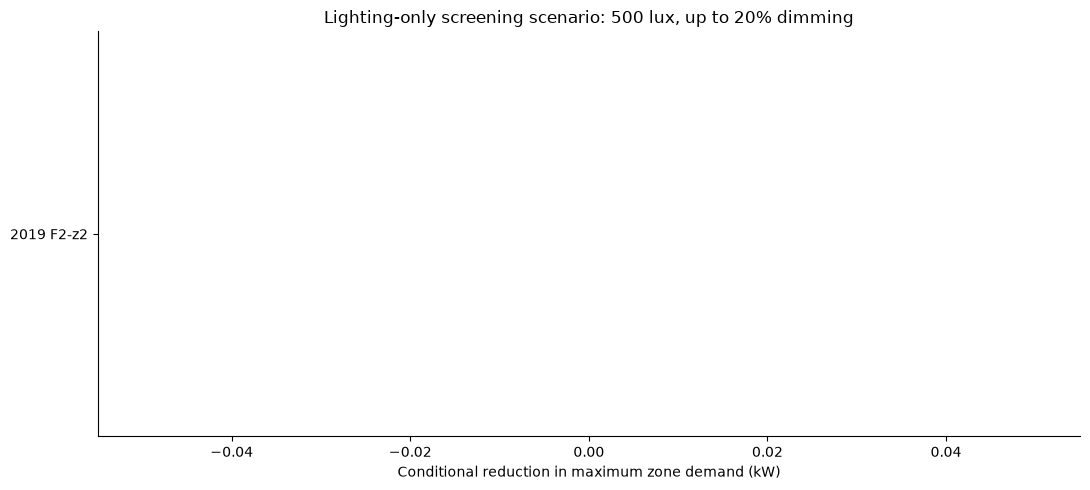

In [7]:
results = []
for (year, zone), g in df.groupby(["year", "zone_id"]):
    g = g.copy()
    valid_total = g["total_kw"].notna()
    work = g["work_hours"]
    pair = g[["total_kw", "light_kw", "lux_min"]].notna().all(axis=1)
    high = g["total_kw"] >= g["total_kw"].quantile(.95)
    pair_coverage = (pair & work).sum() / work.sum() if work.sum() else 0
    peak_pairs = int((pair & work & high).sum())
    if not g["has_lux"].any():
        status = "Demand only: no lux sensor"
    elif pair_coverage < MIN_COVERAGE:
        status = "Review: incomplete paired data"
    elif g.loc[work & pair, "lux_min"].nunique() < 2:
        status = "Review: constant or absent lux"
    elif peak_pairs < MIN_PEAK_PAIRS:
        status = "Review: too few paired peak intervals"
    else:
        status = "Pilot candidate: verify sensor and controls"
    eligible = status.startswith("Pilot")
    peak_index = g["total_kw"].idxmax() if valid_total.any() else None
    for target in LUX_TARGETS:
        fraction = (1 - target / g["lux_min"].replace(0, np.nan)).clip(0, MAX_DIM)
        cut = (g["light_kw"] * fraction).where(pair & work, 0).fillna(0)
        assert (cut >= 0).all()
        assert (cut <= g["light_kw"].fillna(0) * MAX_DIM + 1e-8).all()
        changed = cut > 0
        assert (g.loc[changed, "lux_min"] * (1 - fraction[changed]) >= target - 1e-8).all()
        before = g["total_kw"].max()
        after = (g["total_kw"] - cut).max()
        reduction = before - after
        results.append({"year": year, "zone_id": zone, "target_lux": target,
            "status": status, "pair_coverage_pct": 100 * pair_coverage,
            "peak_pairs": peak_pairs, "baseline_peak_kw": before,
            "cut_at_old_peak_kw": cut.loc[peak_index] if eligible and peak_index is not None else np.nan,
            "scenario_peak_reduction_kw": reduction if eligible else np.nan,
            "scenario_peak_reduction_pct": 100 * reduction / before if eligible and before > 0 else np.nan,
            "mean_cut_high_work_kw": cut[pair & work & high].mean() if eligible else np.nan,
            "high_work_above_target_pct": 100 * g.loc[pair & work & high, "lux_min"].gt(target).mean()})
results = pd.DataFrame(results)
base = results[results["target_lux"] == TARGET_LUX].copy()
display(base.drop(columns="target_lux"))
display(results.pivot_table(index=["year", "zone_id"], columns="target_lux",
                           values="scenario_peak_reduction_kw", dropna=False))

ranked = base.dropna(subset=["scenario_peak_reduction_kw"]).sort_values("scenario_peak_reduction_kw", ascending=False)
if not ranked.empty:
    p = ranked.head(15).sort_values("scenario_peak_reduction_kw")
    plt.barh(p["year"].astype(str) + " " + p["zone_id"], p["scenario_peak_reduction_kw"], color="#267d9c")
    plt.xlabel("Conditional reduction in maximum zone demand (kW)")
    plt.title(f"Lighting-only screening scenario: {TARGET_LUX} lux, up to {MAX_DIM:.0%} dimming")
    plt.tight_layout()
    plt.show()

## 6. Building coincidence and dataset scope

The building proxy below includes all 33 floor-zone pairs at the **same timestamp** and requires complete zone totals. It represents measured channels, not a verified utility main meter. The top-zone contribution is reported at the building proxy's peak to distinguish coincident demand from separate zone maxima.

Keep zones without lux in this demand baseline. Exclude them only from comfort-based optimisation. Avoid dropping an entire floor because one zone has poor sensor coverage. Use the year-specific eligibility table to select valid zone-periods, then inspect the monthly coverage table for outages and comparable study periods.

2018: largest zone contributions at coincident measured peak 2018-07-02 08:00:00


,coincident_kw
zone_id,
F1-z2,116.61
F2-z1,51.21
F4-z1,40.74
F5-z1,39.98
F5-z4,39.70
F6-z4,39.52
F1-z3,38.23
F7-z1,38.06
F3-z4,36.92


2019: largest zone contributions at coincident measured peak 2019-07-30 13:15:00


,coincident_kw
zone_id,
F1-z2,65.17
F2-z1,45.07
F3-z1,43.35
F4-z1,42.08
F4-z4,40.87
F5-z1,40.55
F5-z4,40.51
F7-z1,39.35
F6-z4,38.96


,year,complete_intervals,coverage_pct,peak_time,measured_peak_kw
0,2018,6191,35.05,2018-07-02 08:00:00,891.89
1,2019,14937,42.63,2019-07-30 13:15:00,871.35


year,2018,2019
zone_id,,
F1-z1,Demand only: no lux sensor,Demand only: no lux sensor
F1-z2,Demand only: no lux sensor,Demand only: no lux sensor
F1-z3,Demand only: no lux sensor,Demand only: no lux sensor
F1-z4,Demand only: no lux sensor,Demand only: no lux sensor
F2-z1,Review: incomplete paired data,Review: incomplete paired data
F2-z2,Review: incomplete paired data,Pilot candidate: verify sensor and controls
F2-z3,Review: incomplete paired data,Review: incomplete paired data
F2-z4,Review: incomplete paired data,Review: incomplete paired data
F3-z1,Review: incomplete paired data,Review: incomplete paired data


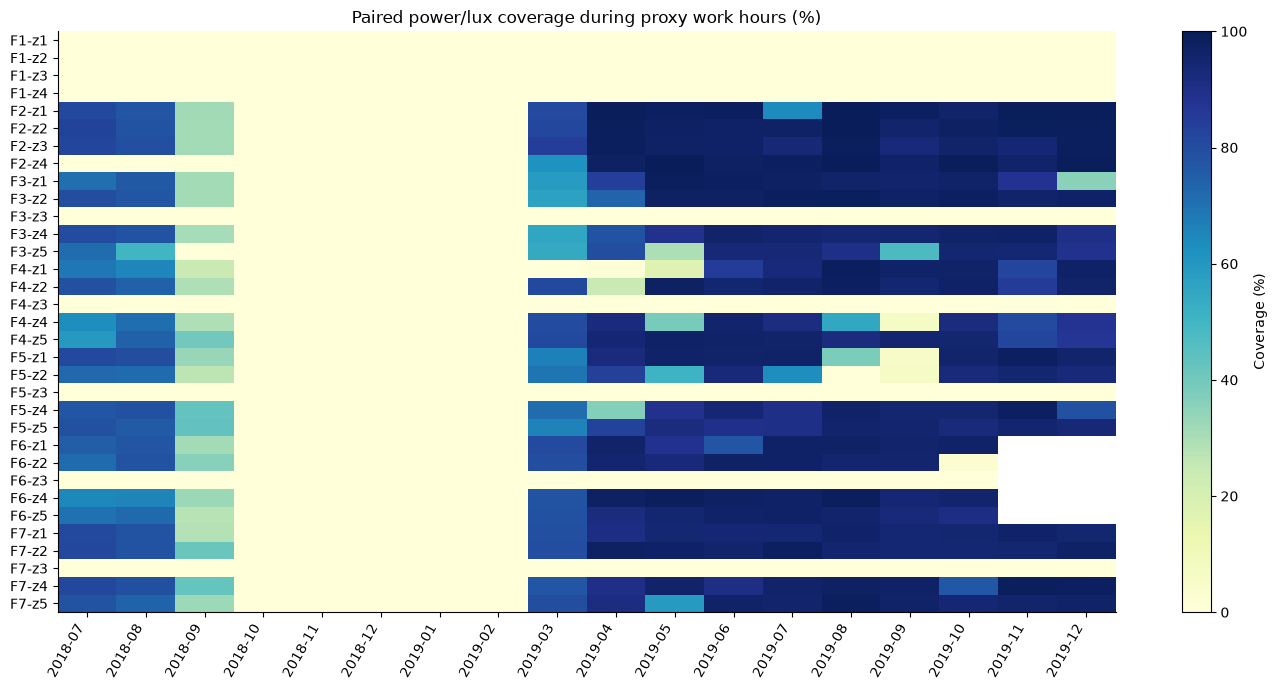

In [8]:
wide = df.pivot(index="Date", columns="zone_id", values="total_kw")
building = wide.sum(axis=1, min_count=wide.shape[1])
building_rows = []
for year, s in building.groupby(building.index.year):
    valid = s.dropna()
    if valid.empty:
        building_rows.append({"year": year, "complete_intervals": 0})
        continue
    time = valid.idxmax()
    building_rows.append({"year": year, "complete_intervals": len(valid),
                          "coverage_pct": 100 * len(valid) / len(s),
                          "peak_time": time, "measured_peak_kw": valid.max()})
    print(f"{year}: largest zone contributions at coincident measured peak {time}")
    display(wide.loc[time].sort_values(ascending=False).head(10).to_frame("coincident_kw"))
building_summary = pd.DataFrame(building_rows)
display(building_summary)
display(base.pivot(index="zone_id", columns="year", values="status"))

# Month-specific availability helps narrow scope to healthy periods rather than delete a floor.
monthly_coverage = df.assign(paired=df[["total_kw", "light_kw", "lux_min"]].notna().all(axis=1))
monthly_coverage = monthly_coverage[monthly_coverage["work_hours"]].groupby(
    [monthly_coverage["Date"].dt.to_period("M"), "zone_id"])["paired"].mean().unstack() * 100
fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(monthly_coverage.T, aspect="auto", vmin=0, vmax=100, cmap="YlGnBu")
ax.set_xticks(range(len(monthly_coverage)), monthly_coverage.index.astype(str), rotation=60, ha="right")
ax.set_yticks(range(len(monthly_coverage.columns)), monthly_coverage.columns)
ax.set_title("Paired power/lux coverage during proxy work hours (%)")
fig.colorbar(im, ax=ax, label="Coverage (%)")
plt.tight_layout()
plt.show()

## 7. Which data is valuable?

| Data | Use and scope recommendation |
|---|---|
| Date + floor + zone | Essential identifiers. Keep floor and zone together; preserve the source clock until timezone is confirmed. |
| Lighting kW + same-zone lux | Core inputs. Retain paired, valid periods; inspect zeros, flat readings, missingness and sensor location. |
| AC and plug kW | Keep for measured total demand and peak timing. Do not claim lighting controls save these loads directly. Plug demand is only an imperfect occupancy clue. |
| Temperature / relative humidity | Keep in raw data and quality audit; exclude from the first simple lighting model. They may explain HVAC demand later. |
| Missing-lux zones | Keep for demand baselines; exclude from comfort-preserving reduction claims until instrumented. |
| All-missing / constant columns | Flag individually. Exclude unusable sensor features; do not silently remove a missing power channel and understate total demand. |
| XLSX versions / extra Floor 2 workbook | Do not concatenate with CSV data. Use one input format; compare formats only if provenance becomes important. |
| Raw minute records | Preserve for sensor checks and intervention validation. Use complete 15-minute intervals for this EDA. |

**Valuable additions:** actual occupancy and operating schedules; room use and agreed task-specific illuminance targets; sensor placement/calibration and multiple workplane measurements; fixture/circuit maps, dimming commands and response curves; daylight/blind status; main-meter demand and tariff interval; occupant feedback and glare/flicker/uniformity measurements. These address gaps that kW and one lux sensor cannot resolve.

**Method reference:** [US DOE lighting controls guidance](https://www.energy.gov/sites/prod/files/2013/10/f3/light_controls.pdf) explains why sensor placement and commissioning matter. [PNNL lighting controls guide](https://integratedlightingcampaign.energy.gov/sites/default/files/2023-01/EED_2058_BROCH_LightingControlsGuide_PNNL-SA-180668.pdf) describes daylight-responsive control against an illuminance target. These sources support the control concept, **not** this notebook's chosen lux thresholds or assumed dimming cap. Dataset provenance is the local CSV filenames listed above; no source data dictionary was supplied.

## 8. Verification

Check uniqueness, input coverage, reduction limits, and the fact that the simulated peak cannot increase. Independently compare one complete aggregated interval with its 15 raw minute records. This verifies the calculation pipeline, not real-world comfort.

In [9]:
assert not df.duplicated(["Date", "zone_id"]).any()
assert df["zone_id"].nunique() == 33
assert files["rows"].sum() > 0
assert (base["scenario_peak_reduction_kw"].dropna() >= -1e-8).all()
assert (base["scenario_peak_reduction_kw"].dropna() <= base.loc[base["scenario_peak_reduction_kw"].notna(), "cut_at_old_peak_kw"] + 1e-8).all()
check = df[(df["year"] == 2018) & (df["zone_id"] == "F2-z1")].dropna(subset=["total_kw"]).iloc[0]
raw_check = pd.read_csv(DATA_DIR / "2018Floor2.csv", parse_dates=["Date"])
window = raw_check[(raw_check["Date"] >= check["Date"]) &
                   (raw_check["Date"] < check["Date"] + pd.Timedelta(minutes=15))]
meter_cols = [c for c in window if c.startswith("z1_") and c.endswith("(kW)")]
assert len(window) == 15
assert np.isclose(window[meter_cols].sum(axis=1).mean(), check["total_kw"])
print("Verified: unique zone timestamps, all 33 zones, scenario bounds, and a raw-data aggregation spot check.")

Verified: unique zone timestamps, all 33 zones, scenario bounds, and a raw-data aggregation spot check.


In [10]:
# Final cell: findings and recommended next steps, generated from the results above.
eligible = base[base["status"].str.startswith("Pilot")]
positive = eligible[eligible["scenario_peak_reduction_kw"] > 1e-8]
no_lux = base[base["status"].str.contains("no lux")]["zone_id"].unique()
top = positive.sort_values("scenario_peak_reduction_kw", ascending=False).head(5)
top_lines = "\n".join(
    f"- {int(r.year)} {r.zone_id}: **{r.scenario_peak_reduction_kw:.2f} kW "
    f"({r.scenario_peak_reduction_pct:.2f}%)** conditional peak reduction."
    for r in top.itertuples()) or "- No positive peak reductions pass the screening rules."
review = base[~base["status"].str.startswith("Pilot") & ~base["status"].str.contains("no lux")]
review_lines = "\n".join(f"- {int(r.year)} {r.zone_id}: {r.status}." for r in review.itertuples())
off = sensors.groupby("zone_id")["offhours_light_kw"].mean().sort_values(ascending=False).head(3)
off_text = ", ".join(f"{z} ({v:.2f} kW)" for z, v in off.items())
display(Markdown(f"""## Findings and recommended steps

**Answer to the business question:** a comfort-preserving reduction is **not yet verified for any zone**. The notebook estimates conditional opportunities; unavailable values are not evidence of zero potential. A measured lux target alone does not establish overall visual comfort.

### Findings from these files
- Analysed **{files['rows'].sum():,} raw rows**, **14 CSV files**, and **33 floor-zone pairs**, from **{files['start'].min():%Y-%m-%d}** to **{files['end'].max():%Y-%m-%d}**. Use the file audit for gaps and unequal year coverage.
- Found **{int(files['exact_duplicates'].sum()):,} exact duplicate rows**, **{int(files['conflict_rows'].sum()):,} conflicting duplicate timestamp rows**, and **{int(columns['negative_n'].sum()):,} negative numeric readings** in the raw audit.
- **{len(eligible)} of {len(base)} zone-years** pass the stated coverage/variation/peak-sample screen. **{len(positive)}** have a positive change in maximum demand in the **{TARGET_LUX}-lux / {MAX_DIM:.0%}-cap** scenario. The per-zone table above includes every zone-year and separates original-peak cuts from reductions in the new maximum.
- **{len(no_lux)} zones have no lux sensor:** {', '.join(no_lux)}. Keep them for demand analysis but exclude them from comfort-based optimisation.
- The largest average off-hours lighting loads are **{off_text}**. Audit their operating schedules; off-hours power is not automatically avoidable waste.

### Largest conditional peak reductions
{top_lines}

These are separate zone-year maxima, **not additive building savings**. See the coincident-demand table for the building context and the 300/500/750-lux table for threshold sensitivity.

### Dataset scope
Start with zone-years labelled **Pilot candidate** and months with high paired coverage. Keep the first model to timestamp, floor-zone, lighting kW, lux, and total measured kW. Retain AC/plug channels to explain peaks; leave temperature/RH out of the first lighting model. Do not discard an entire floor solely because one zone is missing lux. Investigate these additional exclusions before broadening the scope:
{review_lines or '- No additional exclusions under the current screening rules.'}

### Recommended next steps
1. Confirm the meter map, source timezone, actual occupancy, room functions, sensor placement, and required illuminance for each candidate zone. Check suspicious low/flat lux and unusual peaks against raw minute data.
2. Select a small pilot from the conditional ranking only after verifying dimmable circuits and representative workplane readings. Run short controlled dimming steps with live lux feedback, occupant feedback, and immediate restoration when comfort is affected.
3. Recalculate the scenarios using validated power-to-lux responses and room-specific targets. Keep a later time block for validation; compare matched months and occupancy periods instead of mixing unequal years or randomly splitting neighbouring minutes.
4. Evaluate simultaneous changes against the whole-building main meter and actual tariff interval. Report measured kW peak reduction separately from kWh energy savings, and monitor glare, flicker, and spatial uniformity as well as illuminance.
"""))

## Findings and recommended steps

**Answer to the business question:** a comfort-preserving reduction is **not yet verified for any zone**. The notebook estimates conditional opportunities; unavailable values are not evidence of zero potential. A measured lux target alone does not establish overall visual comfort.

### Findings from these files
- Analysed **5,432,489 raw rows**, **14 CSV files**, and **33 floor-zone pairs**, from **2018-07-01** to **2019-12-31**. Use the file audit for gaps and unequal year coverage.
- Found **0 exact duplicate rows**, **0 conflicting duplicate timestamp rows**, and **0 negative numeric readings** in the raw audit.
- **1 of 66 zone-years** pass the stated coverage/variation/peak-sample screen. **0** have a positive change in maximum demand in the **500-lux / 20%-cap** scenario. The per-zone table above includes every zone-year and separates original-peak cuts from reductions in the new maximum.
- **9 zones have no lux sensor:** F1-z1, F1-z2, F1-z3, F1-z4, F3-z3, F4-z3, F5-z3, F6-z3, F7-z3. Keep them for demand analysis but exclude them from comfort-based optimisation.
- The largest average off-hours lighting loads are **F1-z4 (22.77 kW), F1-z3 (21.91 kW), F1-z2 (11.33 kW)**. Audit their operating schedules; off-hours power is not automatically avoidable waste.

### Largest conditional peak reductions
- No positive peak reductions pass the screening rules.

These are separate zone-year maxima, **not additive building savings**. See the coincident-demand table for the building context and the 300/500/750-lux table for threshold sensitivity.

### Dataset scope
Start with zone-years labelled **Pilot candidate** and months with high paired coverage. Keep the first model to timestamp, floor-zone, lighting kW, lux, and total measured kW. Retain AC/plug channels to explain peaks; leave temperature/RH out of the first lighting model. Do not discard an entire floor solely because one zone is missing lux. Investigate these additional exclusions before broadening the scope:
- 2018 F2-z1: Review: incomplete paired data.
- 2018 F2-z2: Review: incomplete paired data.
- 2018 F2-z3: Review: incomplete paired data.
- 2018 F2-z4: Review: incomplete paired data.
- 2018 F3-z1: Review: incomplete paired data.
- 2018 F3-z2: Review: incomplete paired data.
- 2018 F3-z4: Review: incomplete paired data.
- 2018 F3-z5: Review: incomplete paired data.
- 2018 F4-z1: Review: incomplete paired data.
- 2018 F4-z2: Review: incomplete paired data.
- 2018 F4-z4: Review: incomplete paired data.
- 2018 F4-z5: Review: incomplete paired data.
- 2018 F5-z1: Review: incomplete paired data.
- 2018 F5-z2: Review: incomplete paired data.
- 2018 F5-z4: Review: incomplete paired data.
- 2018 F5-z5: Review: incomplete paired data.
- 2018 F6-z1: Review: incomplete paired data.
- 2018 F6-z2: Review: incomplete paired data.
- 2018 F6-z4: Review: incomplete paired data.
- 2018 F6-z5: Review: incomplete paired data.
- 2018 F7-z1: Review: incomplete paired data.
- 2018 F7-z2: Review: incomplete paired data.
- 2018 F7-z4: Review: incomplete paired data.
- 2018 F7-z5: Review: incomplete paired data.
- 2019 F2-z1: Review: incomplete paired data.
- 2019 F2-z3: Review: incomplete paired data.
- 2019 F2-z4: Review: incomplete paired data.
- 2019 F3-z1: Review: incomplete paired data.
- 2019 F3-z2: Review: incomplete paired data.
- 2019 F3-z4: Review: incomplete paired data.
- 2019 F3-z5: Review: incomplete paired data.
- 2019 F4-z1: Review: incomplete paired data.
- 2019 F4-z2: Review: incomplete paired data.
- 2019 F4-z4: Review: incomplete paired data.
- 2019 F4-z5: Review: incomplete paired data.
- 2019 F5-z1: Review: incomplete paired data.
- 2019 F5-z2: Review: incomplete paired data.
- 2019 F5-z4: Review: incomplete paired data.
- 2019 F5-z5: Review: incomplete paired data.
- 2019 F6-z1: Review: incomplete paired data.
- 2019 F6-z2: Review: incomplete paired data.
- 2019 F6-z4: Review: incomplete paired data.
- 2019 F6-z5: Review: incomplete paired data.
- 2019 F7-z1: Review: incomplete paired data.
- 2019 F7-z2: Review: incomplete paired data.
- 2019 F7-z4: Review: incomplete paired data.
- 2019 F7-z5: Review: incomplete paired data.

### Recommended next steps
1. Confirm the meter map, source timezone, actual occupancy, room functions, sensor placement, and required illuminance for each candidate zone. Check suspicious low/flat lux and unusual peaks against raw minute data.
2. Select a small pilot from the conditional ranking only after verifying dimmable circuits and representative workplane readings. Run short controlled dimming steps with live lux feedback, occupant feedback, and immediate restoration when comfort is affected.
3. Recalculate the scenarios using validated power-to-lux responses and room-specific targets. Keep a later time block for validation; compare matched months and occupancy periods instead of mixing unequal years or randomly splitting neighbouring minutes.
4. Evaluate simultaneous changes against the whole-building main meter and actual tariff interval. Report measured kW peak reduction separately from kWh energy savings, and monitor glare, flicker, and spatial uniformity as well as illuminance.
